# Quickstart: NOAA HRRR forecast, 18 hour, virtual - dynamical.org Icechunk Zarr

NOAA's High-Resolution Rapid Refresh (HRRR) is a convection-allowing weather model covering the continental United States at 3 km resolution. This archive contains 18-hour forecasts initialized **every hour** from July 2018 to present. The rapid update cycle makes it especially useful for studying how short-range forecasts evolve as new observations enter the model.

Dataset documentation: https://dynamical.org/catalog/noaa-hrrr-forecast-18-hour-virtual/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy rioxarray

In [2]:
import os

os.environ.setdefault("DYNAMICAL_STAC_CATALOG_URL", "https://stac-staging.dynamical.org/catalog.json")

import dynamical_catalog

ds = dynamical_catalog.open("noaa-hrrr-forecast-18-hour-virtual", chunks=None)
ds

<xarray.Dataset> Size: 3PB
Dimensions:                                                          (
                                                                      init_time: 70492,
                                                                      lead_time: 19,
                                                                      y: 1059,
                                                                      x: 1799)
Coordinates:
  * init_time                                                        (init_time) datetime64[ns] 564kB ...
    expected_forecast_length                                         (init_time) timedelta64[us] 564kB ...
  * lead_time                                                        (lead_time) timedelta64[us] 152B ...
    valid_time                                                       (init_time, lead_time) datetime64[ns] 11MB ...
  * y                                                                (y) float64 8kB ...
  * x                                                                (x) float64 14kB ...
    latitude                                                         (y, x) float32 8MB ...
    longitude                                                        (y, x) float32 8MB ...
    spatial_ref                                                      int64 8B ...
Data variables: (12/142)
    categorical_ice_pellets_surface                                  (init_time, lead_time, y, x) float64 20TB ...
    baseflow_groundwater_runoff_surface                              (init_time, lead_time, y, x) float64 20TB ...
    brightness_temperature_channel_113                               (init_time, lead_time, y, x) float64 20TB ...
    categorical_freezing_rain_surface                                (init_time, lead_time, y, x) float64 20TB ...
    categorical_rain_surface                                         (init_time, lead_time, y, x) float64 20TB ...
    aerosol_optical_thickness_atmosphere                             (init_time, lead_time, y, x) float64 20TB ...
    ...                                                               ...
    visible_diffuse_downward_solar_flux_surface                      (init_time, lead_time, y, x) float64 20TB ...
    wind_gust_surface                                                (init_time, lead_time, y, x) float64 20TB ...
    visibility_surface                                               (init_time, lead_time, y, x) float64 20TB ...
    wind_u_80m                                                       (init_time, lead_time, y, x) float64 20TB ...
    wind_v_10m                                                       (init_time, lead_time, y, x) float64 20TB ...
    wind_v_80m                                                       (init_time, lead_time, y, x) float64 20TB ...
Attributes:
    dataset_id:           noaa-hrrr-forecast-18-hour-virtual
    dataset_version:      0.1.0
    name:                 NOAA HRRR forecast, 18 hour, virtual
    description:          Weather forecasts from the High-Resolution Rapid Re...
    attribution:          NOAA NWS NCEP HRRR data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Continental United States
    spatial_resolution:   3 km
    time_domain:          Forecasts initialized 2018-07-13 12:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every hour
    forecast_domain:      Forecast lead time 0-18 hours ahead
    forecast_resolution:  Hourly

The dataset has two time dimensions: `init_time`, when each forecast cycle began, and `lead_time`, how far that cycle extends into the future. Their sum is the two-dimensional `valid_time` coordinate.

HRRR uses a 3 km Lambert Conformal grid indexed by projected `x` and `y` coordinates. Two-dimensional `latitude` and `longitude` coordinates and the grid's spatial reference are included. Surface variables live at the dataset root; variables on vertical levels live in the `pressure_level` and `model_level` groups.

The examples below focus on what distinguishes this archive from the 48-hour product: consecutive hourly cycles can be compared at the same valid time or joined into a continuously refreshed short-range forecast.

### How did the forecast change with each hourly update?

Six consecutive HRRR cycles all forecast the atmosphere at 22 UTC on 21 May 2024, when severe storms were crossing Iowa. Pairing each `init_time` with the appropriate `lead_time` extracts a diagonal through the two forecast dimensions: every panel has the same `valid_time`, but each incorporates one more hour of observations than the panel before it.

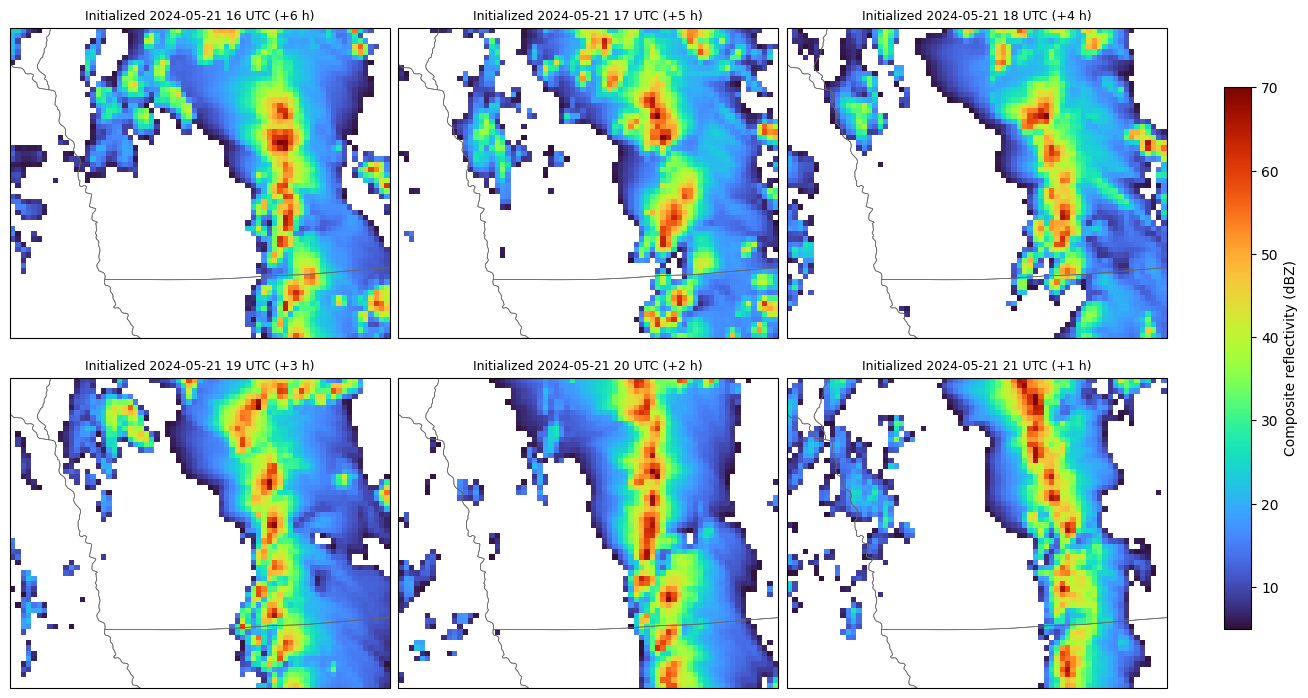

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # enables the .rio accessor
import xarray as xr

crs = ds.spatial_ref.attrs
hrrr_proj = ccrs.LambertConformal(
    central_longitude=crs["longitude_of_central_meridian"],
    central_latitude=crs["latitude_of_projection_origin"],
    standard_parallels=crs["standard_parallel"],
    globe=ccrs.Globe(
        semimajor_axis=crs["semi_major_axis"],
        semiminor_axis=crs["semi_minor_axis"],
    ),
)

target_valid_time = np.datetime64("2024-05-21T22:00")
init_times = np.arange(
    np.datetime64("2024-05-21T16:00"),
    np.datetime64("2024-05-21T22:00"),
    np.timedelta64(1, "h"),
)
lead_times = target_valid_time - init_times

reflectivity_runs = (
    ds["composite_reflectivity"]
    .sel(
        init_time=xr.DataArray(init_times, dims="run"),
        lead_time=xr.DataArray(lead_times, dims="run"),
    )
    .rio.clip_box(-97, 40, -92, 43, crs="EPSG:4326")
    .coarsen(x=2, y=2, boundary="trim")
    .mean()
    .load()
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 7),
    subplot_kw={"projection": hrrr_proj},
    constrained_layout=True,
)
for i, ax in enumerate(axes.flat):
    image = reflectivity_runs.isel(run=i).where(reflectivity_runs.isel(run=i) > 5).plot(
        ax=ax,
        transform=hrrr_proj,
        cmap="turbo",
        vmin=5,
        vmax=70,
        add_colorbar=False,
    )
    ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
    init_label = np.datetime_as_string(init_times[i], unit="h").replace("T", " ")
    lead_hours = int(lead_times[i] / np.timedelta64(1, "h"))
    ax.set_title(f"Initialized {init_label} UTC (+{lead_hours} h)", fontsize=9)

fig.colorbar(image, ax=axes, label="Composite reflectivity (dBZ)", shrink=0.8)

### Run-to-run consistency at a point

Hourly initialization also makes forecast stability visible. These seven consecutive cycles cover overlapping valid times at Kansas City during the sharp cold-frontal passage of 14 March 2025. Agreement between the lines indicates a stable forecast; changes in their timing or magnitude show where the newest cycle revised the forecast.

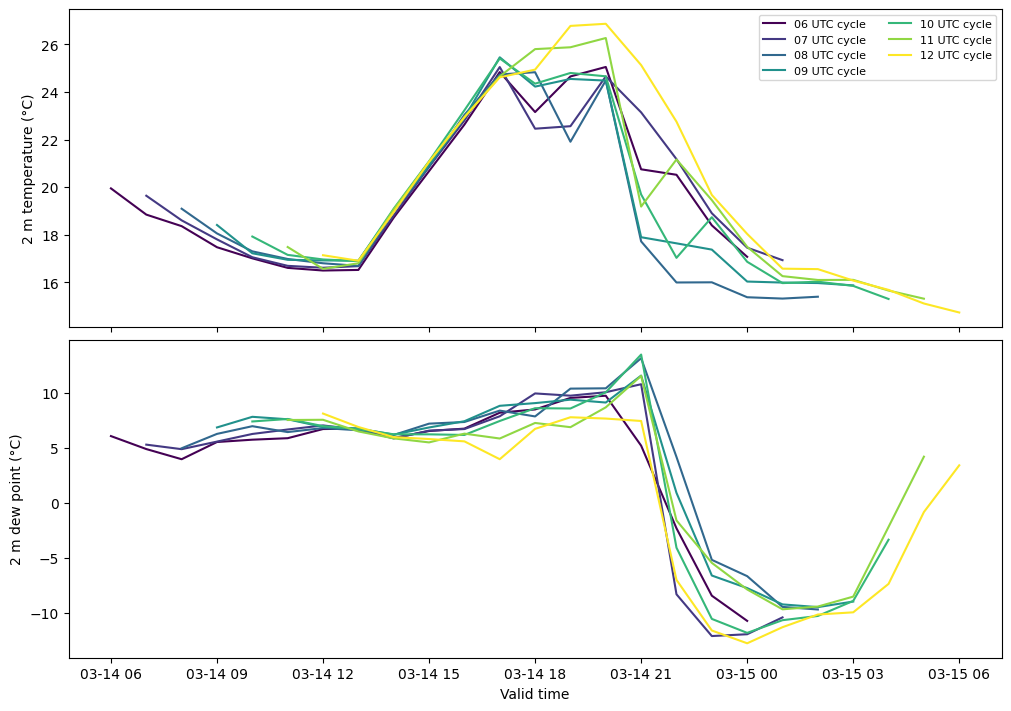

In [4]:
from pyproj import Transformer

to_xy = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x_kc, y_kc = to_xy.transform(-94.58, 39.10)
point_init_times = np.arange(
    np.datetime64("2025-03-14T06:00"),
    np.datetime64("2025-03-14T13:00"),
    np.timedelta64(1, "h"),
)

kc_runs = (
    ds[["temperature_2m", "dew_point_temperature_2m"]]
    .sel(init_time=point_init_times)
    .sel(x=x_kc, y=y_kc, method="nearest")
    .load()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(point_init_times)))
for i, (init_time, color) in enumerate(zip(point_init_times, colors, strict=True)):
    label = f"{np.datetime_as_string(init_time, unit='h')[11:]} UTC cycle"
    valid_time = kc_runs.valid_time.isel(init_time=i)
    axes[0].plot(valid_time, kc_runs.temperature_2m.isel(init_time=i), color=color, label=label)
    axes[1].plot(valid_time, kc_runs.dew_point_temperature_2m.isel(init_time=i), color=color)

axes[0].set_ylabel("2 m temperature (°C)")
axes[1].set_ylabel("2 m dew point (°C)")
axes[1].set_xlabel("Valid time")
axes[0].legend(ncol=2, fontsize=8)

### A continuously refreshed one-hour precipitation forecast

`total_precipitation_run_total_surface` resets at every initialization, so its value at lead hour 1 is the precipitation forecast during the first hour of that cycle. Joining those values by `valid_time` produces a continuous series that is refreshed from a new model initialization every hour.

Here the rolling one-hour forecast follows Hurricane Milton's rainfall near Tampa during 9 October 2024. The units `kg m-2` are numerically equivalent to millimetres of liquid water.

Text(0.5, 0, 'Valid time')

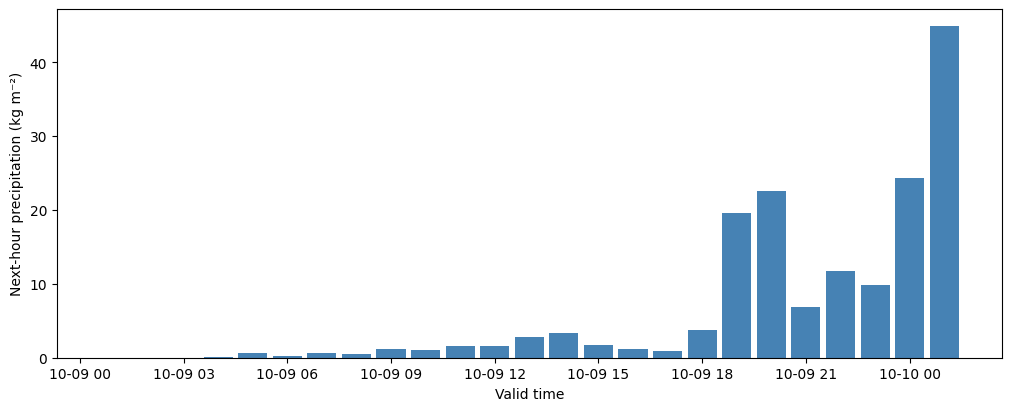

In [5]:
x_tampa, y_tampa = to_xy.transform(-82.46, 27.95)
rolling_qpf = (
    ds["total_precipitation_run_total_surface"]
    .sel(
        init_time=slice("2024-10-09T00", "2024-10-10T00"),
        lead_time="1h",
    )
    .sel(x=x_tampa, y=y_tampa, method="nearest")
    .load()
)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(rolling_qpf.valid_time, rolling_qpf, width=0.035, color="steelblue")
ax.set_ylabel("Next-hour precipitation (kg m⁻²)")
ax.set_xlabel("Valid time")

### How did the forecast vertical profile change?

Variables on pressure levels live in the `pressure_level` group. The same paired-indexing approach compares three hourly cycles at one valid time and location in the inflow to the Greenfield, Iowa supercell. Solid lines are temperature and dashed lines are dew point; movement between cycles shows how the forecast thermodynamic profile evolved as the event approached.

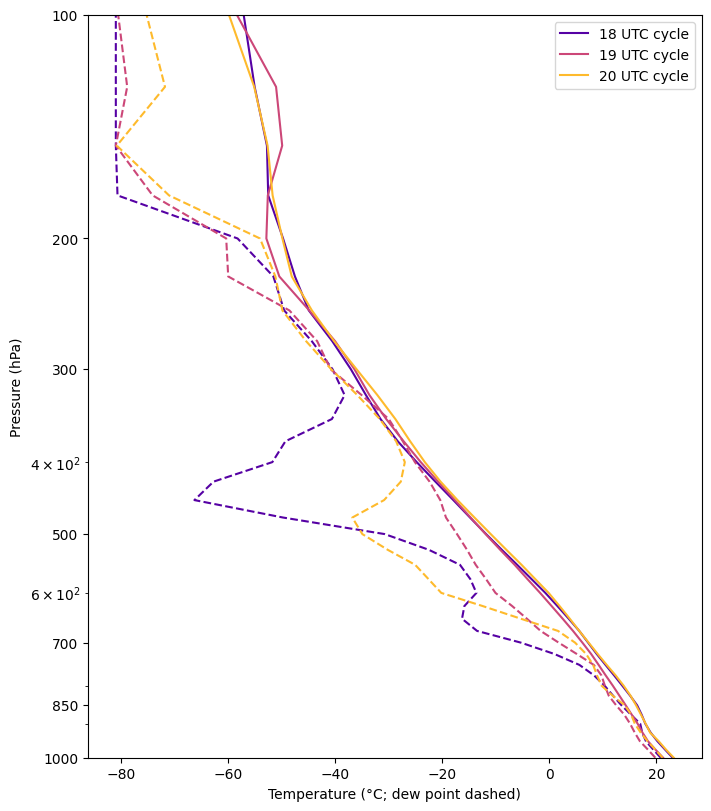

In [6]:
ds_pressure = dynamical_catalog.open(
    "noaa-hrrr-forecast-18-hour-virtual",
    group="pressure_level",
    chunks=None,
)

profile_valid_time = np.datetime64("2024-05-21T21:00")
profile_init_times = np.arange(
    np.datetime64("2024-05-21T18:00"),
    np.datetime64("2024-05-21T21:00"),
    np.timedelta64(1, "h"),
)
profile_lead_times = profile_valid_time - profile_init_times
x_greenfield, y_greenfield = to_xy.transform(-94.46, 41.31)

profiles = (
    ds_pressure[["temperature", "dew_point_temperature"]]
    .sel(
        init_time=xr.DataArray(profile_init_times, dims="run"),
        lead_time=xr.DataArray(profile_lead_times, dims="run"),
    )
    .sel(x=x_greenfield, y=y_greenfield, method="nearest")
    .load()
)

fig, ax = plt.subplots(figsize=(7, 8), constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(profile_init_times)))
for i, (init_time, color) in enumerate(zip(profile_init_times, colors, strict=True)):
    label = f"{np.datetime_as_string(init_time, unit='h')[11:]} UTC cycle"
    profile = profiles.isel(run=i)
    ax.plot(profile.temperature, profile.pressure_level, color=color, label=label)
    ax.plot(profile.dew_point_temperature, profile.pressure_level, color=color, linestyle="--")

ax.set_yscale("log")
ax.set_ylim(1000, 100)
ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
ax.set_yticklabels(["1000", "850", "700", "500", "300", "200", "100"])
ax.set_xlabel("Temperature (°C; dew point dashed)")
ax.set_ylabel("Pressure (hPa)")
ax.legend()

### Community challenges

- **Build a time-lagged ensemble.** At one valid time, combine forecasts from several recent hourly cycles and map the fraction exceeding a threshold for wind gust, reflectivity, or updraft helicity. The cycles are related, so describe this as a time-lagged ensemble rather than an independent probabilistic ensemble.
- **Measure short-range error growth.** Compare forecasts at lead hours 1, 3, 6, 12, and 18 against the companion [NOAA HRRR analysis](https://dynamical.org/catalog/noaa-hrrr-analysis/) at matching valid times.
- **Track solar ramps.** Use consecutive hourly forecasts of `downward_short_wave_radiation_flux_surface` to see whether a cloud-driven power ramp becomes more consistent as its valid time approaches.

For longer forecast trajectories, storm-total swaths, 3-D hydrometeor visualization, and a full-event animation, see the [NOAA HRRR 48-hour virtual quickstart](https://github.com/dynamical-org/notebooks/blob/main/noaa-hrrr-forecast-48-hour-virtual.ipynb).